In [57]:
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt
from tqdm import tqdm

# Background

The equation of a damped harmonic oscillator is

$$
\ddot{x} + 2\gamma\dot{x} + \omega_0^2x = 0
$$

which admits the solution in the underdamped regime ($\gamma<\omega_0$):

$$
x(t) = e^{-\gamma t} \left[x_0 \cos{\omega_1 t} + \frac{v_0 + \gamma x_0}{\omega_1}\sin{\omega_1 t}\right]
$$

where $\omega_1^2=\omega_0^2-\gamma^2$ is the dampened frequency.

In [6]:
def harmonic_oscillator(t, x0, v0, gam, omeg0):
    omeg1 = jnp.sqrt(omeg0**2 - gam**2)
    pref = (v0 + gam*x0)/omeg1
    ans = x0 * jnp.cos(omeg1*t) + pref * jnp.sin(omeg1*t)
    print(omeg1, pref)
    return jnp.exp(-gam*t)*ans

1.9364917 0.5163978


(-2.2, 2.2)

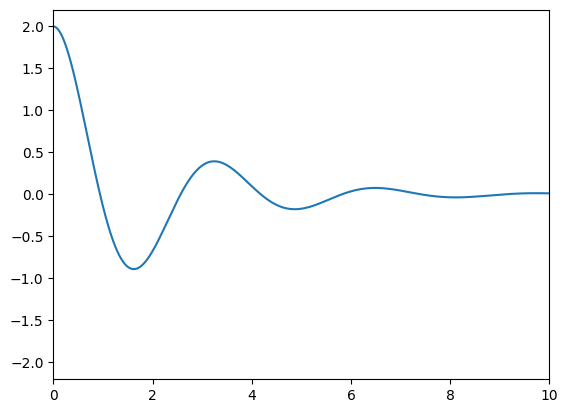

In [19]:
tlist = np.linspace(0, 10, 1000)

x0 = 2
v0 = 0
gam = 0.5
omeg0 = 2

x_t = harmonic_oscillator(tlist, x0, v0, gam, omeg0)

plt.plot(tlist, x_t)
plt.xlim(0, 10)
plt.ylim(-2.2, 2.2)

## Training

Now let's fix the initial conditions and values of gamma and omega0, and train a network to predict x(t) at a time t between 0 and 10 given an initial x0 and v0.

In [ ]:
X0 = 2
V0 = 0.5
GAMMA  = 0.5
OMEGA0 = 2

1.9364917 0.77459663


(-2.2, 2.2)

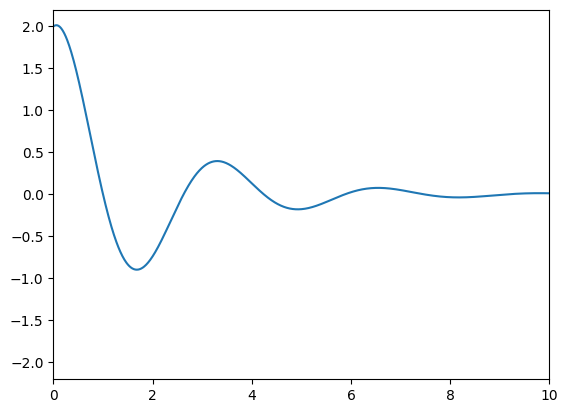

In [24]:
tlist = np.linspace(0, 10, 1000)

x_t = harmonic_oscillator(tlist, X0, V0, GAMMA, OMEGA0)

plt.plot(tlist, x_t)
plt.xlim(0, 10)
plt.ylim(-2.2, 2.2)

In [96]:
def init_mlp(key, layer_sizes):
    params = []
    for i in range(len(layer_sizes)-1):
        key, subkey = jr.split(key)
        scale = jnp.sqrt(2.0/layer_sizes[i])
        w = jr.normal(subkey, (layer_sizes[i], layer_sizes[i+1]))*scale
        b = jnp.zeros(layer_sizes[i+1])
        params.append((w, b))
    return params

def forward(params, t, gamma, omega0):
    x = jnp.array([t, gamma, omega0])
    for w, b in params[:-1]:
        x = jnp.tanh(x @ w + b)
    w, b = params[-1]
    return (x @ w + b).squeeze()

dx_dt = jax.grad(forward, argnums=1)
d2x_dt2 = jax.grad(dx_dt, argnums=1)

def loss_fn(params, t_colloc, gamma, omega0):
    def ode_residual(t, gamma, omega0):
        x = forward(params, t, gamma, omega0)
        x_t = dx_dt(params, t, gamma, omega0)
        x_tt = d2x_dt2(params, t, gamma, omega0)
        return x_tt + 2*gamma*x_t + omega0**2 * x

    residuals = jax.vmap(ode_residual, in_axes=(0,None,None))(t_colloc, gamma, omega0)
    physics_loss = jnp.mean(residuals**2)

    # initial conditions
    ic_loss = (forward(params, 0., gamma, omega0) - X0)**2 + (dx_dt(params, 0., gamma, omega0) - V0)**2
    
    return physics_loss + 10 * ic_loss

In [103]:
key = jr.PRNGKey(42)
params = init_mlp(key, [3, 128, 128, 1])
forward(params, 1, 0.5, 2.)
# loss_fn(params, jnp.array([1.0, 0.5, 0.2]))

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

In [104]:
@jax.jit
def train_step(params, opt_state, t_colloc, gamma, omega0):
    loss, grads = jax.value_and_grad(loss_fn)(params, t_colloc, gamma, omega0)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

loss_trace = np.zeros(10_000)
for epoch in (pbar := tqdm(range(10_000))):
    key, subkey = jr.split(key)
    t_colloc = jr.uniform(subkey, (100,), minval=0.0, maxval=5.0)
    gamma = jr.uniform(subkey, (1,), minval=0.0, maxval=0.8)[0]
    omega0 = jr.uniform(subkey, (1,), minval=1.0, maxval=2.0)[0]
    params, opt_state, loss = train_step(params, opt_state, t_colloc, gamma, omega0)
    loss_trace[epoch] = loss
    if epoch % 2000 == 0:
        pbar.set_postfix(loss=f"{loss:.2e}")

100%|██████████| 10000/10000 [00:09<00:00, 1004.28it/s, loss=1.82e-02]


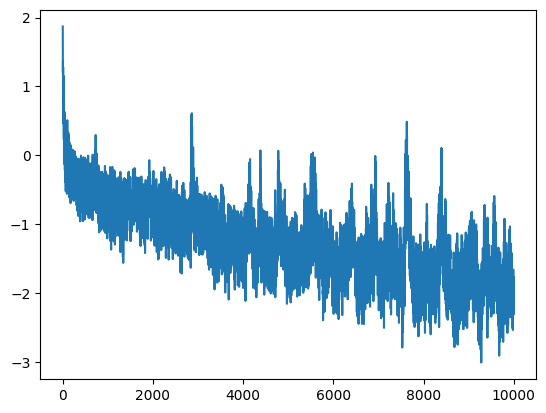

In [105]:
plt.plot(np.log10(loss_trace))

1.9364917 0.77459663


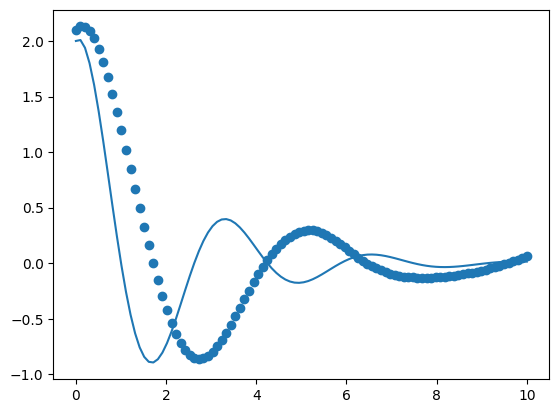

In [107]:
tlist = jnp.linspace(0, 10, 100)
xlist = jax.vmap(forward, in_axes=(None, 0, None, None))(params, tlist, GAMMA, OMEGA0)
xlist_true = harmonic_oscillator(tlist, X0, V0, GAMMA, OMEGA0)

plt.plot(tlist, xlist_true)
plt.scatter(tlist, xlist)